# Shallow vs Deep Learning, the XOR problem
In this notebook with highlight the difference between shallow and deep learning by comparing logistic regression and a small fully connected neural network on the XOR problem.
In the XOR problem, where the inputs are binary (0 or 1) and the output is also binary, logistic regression fails to capture the nonlinear relationship between inputs and outputs. 

| Input 1 | Input 2 | XOR |
|---------|---------|-----|
|    0    |    0    |  0  |
|    0    |    1    |  1  |
|    1    |    0    |  1  |
|    1    |    1    |  0  |

Logistic regression cannot draw a single straight line to separate the outputs 0 and 1 effectively, making it inadequate for solving the XOR problem.

In contrast, a deep neural network can learn the nonlinear relationships in the XOR problem. An MLP with at least one hidden layer (even a single hidden layer with two neurons) can solve the XOR problem effectively by learning the nonlinear mapping between inputs and outputs.

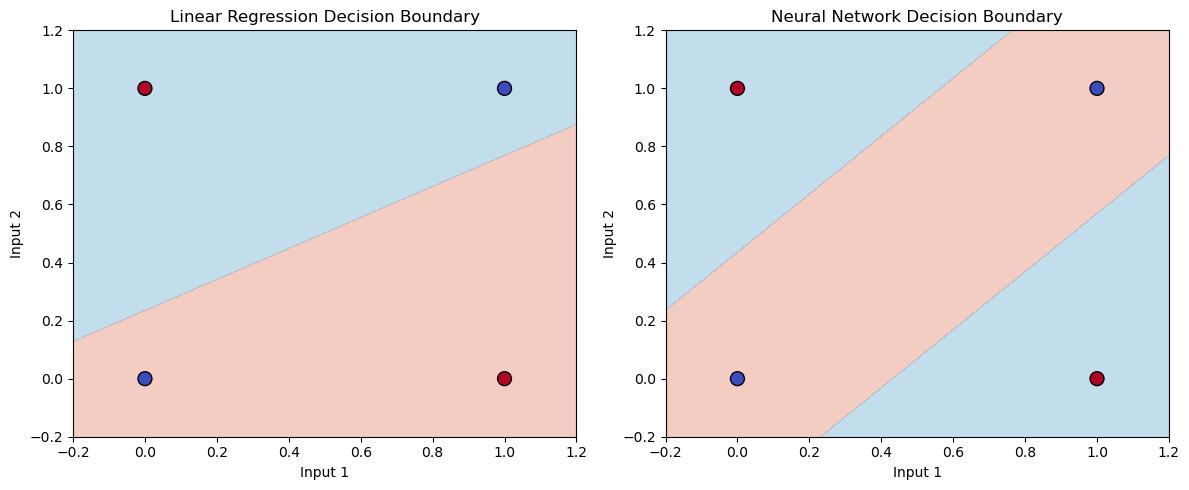

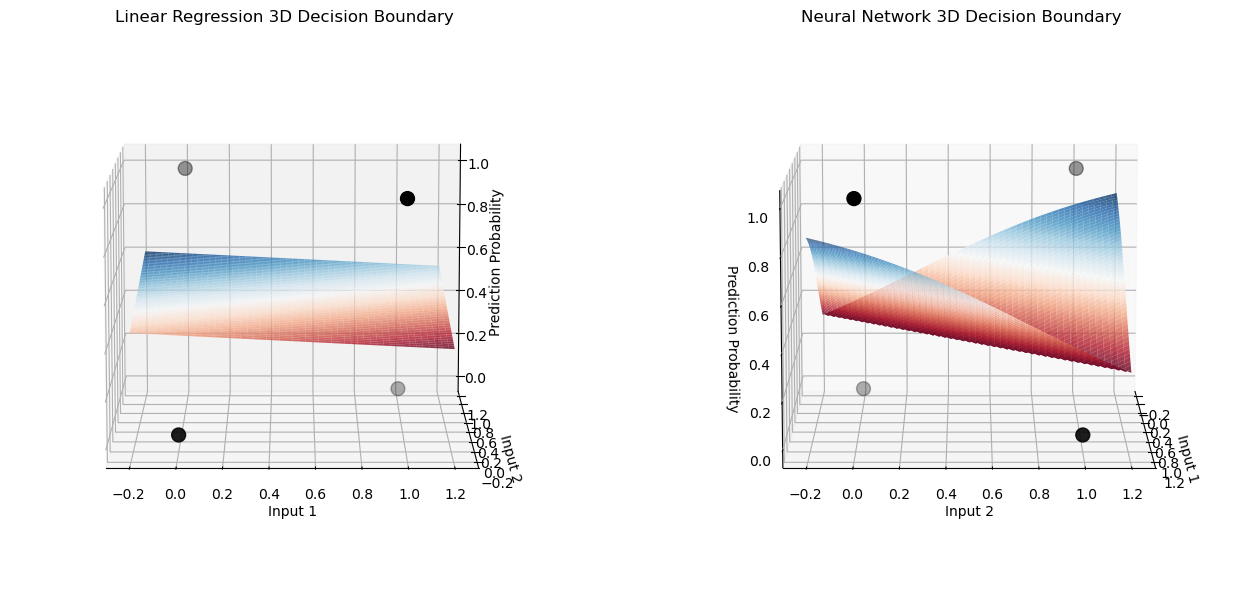

In [8]:
# Author: Roberto Doriguzzi-Corin
# Project: Course on Network Intrusion and Anomaly Detection with Machine Learning
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#   http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import pyshark

# We need the following to get around “RuntimeError: This event loop is already running” when using Pyshark within Jupyter notebooks.
# Not needed in stand-alone Python projects

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.linear_model import LinearRegression
import tensorflow as tf

SEED = 1
# Set random seed for NumPy
np.random.seed(SEED)

# Set random seed for TensorFlow
tf.random.set_seed(SEED)

# XOR Data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Logisti regression model
linear_reg = Sequential()
linear_reg.add(Dense(1, input_dim=2, activation='sigmoid'))
linear_reg.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
linear_reg.fit(X, y, epochs=1000, verbose=0)


# 2-Layer Neural Network Model
model = Sequential()
model.add(Dense(2, input_dim=2, activation='relu'))  # Hidden layer with 8 neurons and ReLU activation
model.add(Dense(1, activation='sigmoid'))  # Output layer with 1 neuron and sigmoid activation (for binary classification)
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])
model.fit(X, y, epochs=1000, verbose=0)

# Plot Decision Boundaries
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 400), np.linspace(-0.2, 1.2, 400))
zz_linear_reg = linear_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
zz_nn = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plotting
plt.figure(figsize=(12, 5))

# Linear Regression Decision Boundary
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, zz_linear_reg, levels=[0, 0.5, 1], cmap='RdBu', alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=100)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('Linear Regression Decision Boundary')

# Neural Network Decision Boundary
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, zz_nn, levels=[0, 0.5, 1], cmap='RdBu', alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=100)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('Neural Network Decision Boundary')

plt.tight_layout()
plt.show()


# 3D Plotting with Rotation
fig = plt.figure(figsize=(14, 6))

# Linear Regression 3D Plot
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(xx, yy, zz_linear_reg, cmap='RdBu', alpha=0.8)
ax.scatter(X[:, 0], X[:, 1], y, color='black', s=100, label='True Labels')
ax.set_xlabel('Input 1')
ax.set_ylabel('Input 2')
ax.set_zlabel('Prediction Probability')
ax.set_title('Linear Regression 3D Decision Boundary')
ax.view_init(elev=10, azim=-90)  # Set the elevation and azimuth angles

# Neural Network 3D Plot
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot_surface(xx, yy, zz_nn, cmap='RdBu', alpha=0.8)
ax.scatter(X[:, 0], X[:, 1], y, color='black', s=100, label='True Labels')
ax.set_xlabel('Input 1')
ax.set_ylabel('Input 2')
ax.set_zlabel('Prediction Probability')
ax.set_title('Neural Network 3D Decision Boundary')
ax.view_init(elev=10, azim=-90)  # Set the elevation and azimuth angles

plt.tight_layout()
plt.show()

